# Body Comp: Ultrasound with a  Wavelet U-Net model (Extracting the HAAR wavelet features)

This condensed notebook uses **one shared preprocessing path**:

(cropped images are saved in the drive under processed images)
making two FM/FFM prediction approaches:
   - Haar feature extraction to ridge regression after comparing to random forest
   - Raw image + resized Haar features (coefficients of running this wavelet analysis become part of the input into the U-Net encoder

All splits are patient-level. Test patients are untouched until final evaluation.

## 0. Install and imports

In [1]:
!pip install -q PyWavelets opencv-python-headless scikit-learn seaborn tqdm torch torchvision

In [2]:
import os, re, glob, random, warnings, json, joblib
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pywt
from scipy.stats import skew, kurtosis
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())

PyTorch: 2.11.0+cu128 | CUDA: True


## 1. Configuration

In [3]:
# Mount before resolving Drive paths.
from google.colab import drive
drive.mount('/content/gdrive')

# Google Drive paths may contain one wildcard. resolve_one() expands it safely.
ROOT_GLOB = '/content/gdrive/MyDrive/Body Composition 2026/*ultrasound_images_cropped'
MASTER_GLOB = '/content/gdrive/MyDrive/Body Composition 2026/*dataset_info/manifests/master_patients_probe.csv'

# Set these explicitly if automatic column selection chooses incorrectly.
PID_COL = None
FM_COL = None
FFM_COL = None

SEED = 30
IMG_SIZE = (256, 256)                    # (width, height) for OpenCV
REGION_CROP_FRAC = {'ABD': 1.0, 'BICEP': 1.0, 'QUAD': 1.0}
CROP_BORDERS = {
    'ABD':   (0.06, 0.06, 0.04, 0.10),  # left, right, top, bottom
    'BICEP': (0.06, 0.06, 0.04, 0.10),
    'QUAD':  (0.06, 0.06, 0.04, 0.10),
}

HAAR_LEVEL = 1
BATCH_SIZE = 16
EPOCHS = 60
LEARNING_RATE = 1e-3
PATIENCE = 10
NUM_WORKERS = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

def resolve_one(pattern):
    matches = sorted(glob.glob(pattern))
    if len(matches) != 1:
        raise FileNotFoundError(f'Expected exactly one match for {pattern!r}; found {matches}')
    return Path(matches[0])

ROOT_DIR = resolve_one(ROOT_GLOB)
MASTER = resolve_one(MASTER_GLOB)
OUTPUT_DIR = ROOT_DIR.parent / 'wavelet_unet_results'
PROCESSED_DIR = OUTPUT_DIR / 'processed_images'
FIG_DIR = OUTPUT_DIR / 'figures'
MODEL_DIR = OUTPUT_DIR / 'models'
for folder in (OUTPUT_DIR, PROCESSED_DIR, FIG_DIR, MODEL_DIR): folder.mkdir(parents=True, exist_ok=True)

print('Images:', ROOT_DIR)
print('Labels:', MASTER)
print('All outputs:', OUTPUT_DIR)

Mounted at /content/gdrive
Images: /content/gdrive/MyDrive/Body Composition 2026/*ultrasound_images_cropped
Labels: /content/gdrive/MyDrive/Body Composition 2026/*dataset_info/manifests/master_patients_probe.csv
All outputs: /content/gdrive/MyDrive/Body Composition 2026/wavelet_unet_results


## 2. Load paths and merge FM/FFM labels

In [4]:
IMG_EXTS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}
REGION_PATTERNS = {
    'ABD': re.compile(r'abd|abdom|stomach|belly', re.I),
    'BICEP': re.compile(r'bic|bicep|arm', re.I),
    'QUAD': re.compile(r'quad|thigh|leg', re.I),
}

def infer_region(path):
    text = str(path)
    for region, pattern in REGION_PATTERNS.items():
        if pattern.search(text): return region
    return 'UNKNOWN'

def infer_pid(path):
    # Prefer a numeric directory component; fall back to any 3–6 digit token.
    parts = Path(path).parts
    candidates = [p for p in parts if re.fullmatch(r'0*\d{3,6}', p)]
    if candidates: return candidates[-1].lstrip('0') or '0'
    match = re.search(r'(?<!\d)(\d{3,6})(?!\d)', str(path))
    return (match.group(1).lstrip('0') or '0') if match else 'UNKNOWN'

image_paths = sorted(p for p in ROOT_DIR.rglob('*') if p.suffix.lower() in IMG_EXTS)
df_paths = pd.DataFrame({'source_path': [str(p) for p in image_paths]})
df_paths['region'] = df_paths['source_path'].map(infer_region)
df_paths['patient_id'] = df_paths['source_path'].map(infer_pid)
print('Images found:', len(df_paths))
print(df_paths['region'].value_counts(dropna=False))

df_master = pd.read_csv(MASTER)
cols = list(df_master.columns)

def first_matching(explicit, predicates, label):
    if explicit is not None:
        if explicit not in cols: raise KeyError(f'{label} column {explicit!r} not found')
        return explicit
    candidates = [c for c in cols if any(p(c.lower()) for p in predicates)]
    if not candidates: raise KeyError(f'Could not infer {label}; available columns: {cols}')
    print(f'{label} candidates:', candidates, '→ using', candidates[0])
    return candidates[0]

PID_COL = first_matching(PID_COL, [lambda s: any(k in s for k in ('patient', 'subject', 'participant', 'pid')), lambda s: s == 'id'], 'patient ID')
FM_COL = first_matching(FM_COL, [lambda s: ('fat' in s and 'free' not in s and 'ffm' not in s)], 'fat mass')
FFM_COL = first_matching(FFM_COL, [lambda s: ('fat_free' in s or 'fat free' in s or 'ffm' in s or 'lean' in s)], 'fat-free mass')

df_master[PID_COL] = df_master[PID_COL].astype(str).str.strip().str.replace(r'\.0$', '', regex=True).str.lstrip('0').replace('', '0')
for col in (FM_COL, FFM_COL): df_master[col] = pd.to_numeric(df_master[col], errors='coerce')

df = df_paths.merge(
    df_master[[PID_COL, FM_COL, FFM_COL]].drop_duplicates(PID_COL),
    left_on='patient_id', right_on=PID_COL, how='left', validate='many_to_one'
)
df = df[df['region'].isin(REGION_CROP_FRAC)].dropna(subset=[FM_COL, FFM_COL]).reset_index(drop=True)
print(f'Matched labeled images: {len(df)} | patients: {df.patient_id.nunique()}')
display(df.head())

Images found: 1322
region
QUAD     481
BICEP    422
ABD      419
Name: count, dtype: int64
patient ID candidates: ['patient_id'] → using patient_id
fat mass candidates: ['fat_mass'] → using fat_mass
fat-free mass candidates: ['fat_free_mass'] → using fat_free_mass
Matched labeled images: 286 | patients: 26


,source_path,region,patient_id,fat_mass,fat_free_mass
0,/content/gdrive/MyDrive/Body Composition 2026/...,ABD,1001,0.1236,2.2436
1,/content/gdrive/MyDrive/Body Composition 2026/...,ABD,1001,0.1236,2.2436
2,/content/gdrive/MyDrive/Body Composition 2026/...,ABD,1001,0.1236,2.2436
3,/content/gdrive/MyDrive/Body Composition 2026/...,BICEP,1001,0.1236,2.2436
4,/content/gdrive/MyDrive/Body Composition 2026/...,BICEP,1001,0.1236,2.2436


## 3. Crop once, keep bone pixels, and save processed images

In [5]:
def crop_borders(image, region):
    left, right, top, bottom = CROP_BORDERS.get(region, (0, 0, 0, 0))
    h, w = image.shape
    x0, x1 = int(w * left), w - int(w * right)
    y0, y1 = int(h * top), h - int(h * bottom)
    return image[y0:y1, x0:x1] if x1 > x0 and y1 > y0 else image

def preprocess_and_save(row):
    image = cv2.imread(row.source_path, cv2.IMREAD_GRAYSCALE)
    if image is None or image.size == 0: return None
    frac = REGION_CROP_FRAC[row.region]
    image = image[:max(1, int(image.shape[0] * frac)), :]
    image = crop_borders(image, row.region)
    if image.size == 0 or image.std() < 0.5: return None

    # Intentionally NO bone mask. Bone and acoustic shadow remain in the image.
    image = cv2.resize(image, IMG_SIZE, interpolation=cv2.INTER_AREA)
    safe_stem = re.sub(r'[^A-Za-z0-9_-]+', '_', Path(row.source_path).stem)
    name = f'{row.patient_id}_{row.region}_{row.Index:05d}_{safe_stem}.png'
    output_path = PROCESSED_DIR / name
    cv2.imwrite(str(output_path), image)
    return str(output_path)

processed = []
for row in tqdm(df.itertuples(), total=len(df), desc='Crop + save'):
    processed.append(preprocess_and_save(row))
df['processed_path'] = processed
df = df.dropna(subset=['processed_path']).reset_index(drop=True)
df.to_csv(OUTPUT_DIR / 'processed_manifest.csv', index=False)
print(f'Saved {len(df)} reusable images to {PROCESSED_DIR}')

Crop + save:   0%|          | 0/286 [00:00<?, ?it/s]

Saved 286 reusable images to /content/gdrive/MyDrive/Body Composition 2026/wavelet_unet_results/processed_images


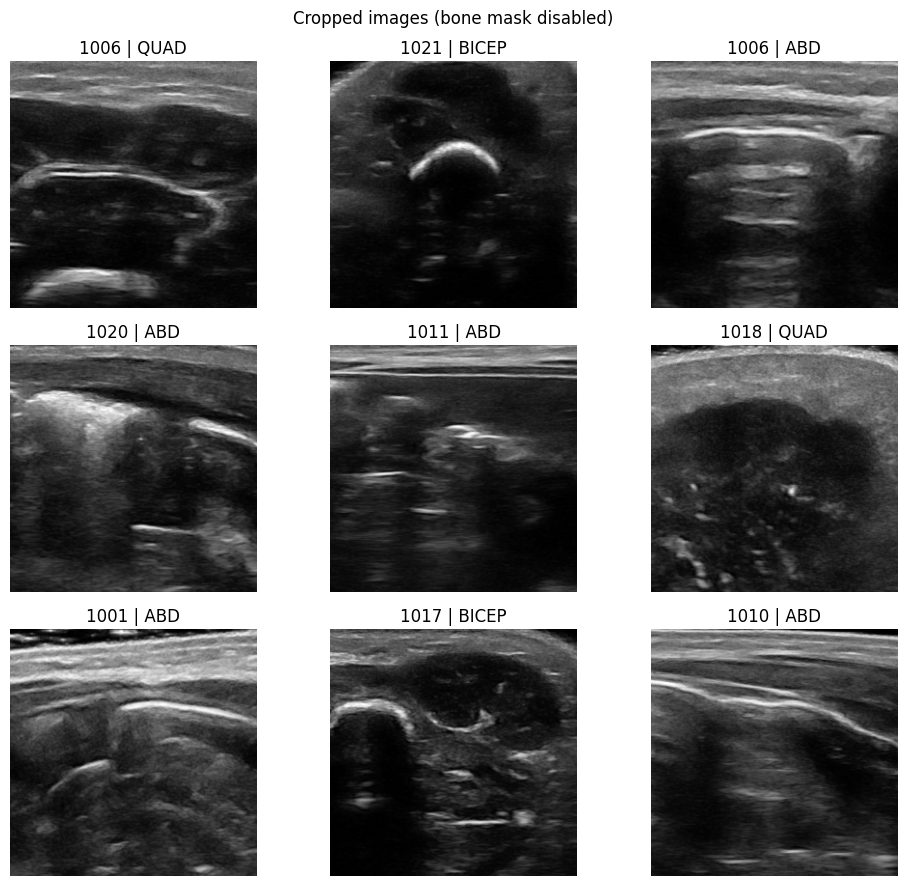

In [6]:
sample = df.sample(min(9, len(df)), random_state=SEED)
fig, axes = plt.subplots(3, 3, figsize=(10, 9))
for ax in axes.ravel(): ax.axis('off')
for ax, row in zip(axes.ravel(), sample.itertuples()):
    ax.imshow(cv2.imread(row.processed_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
    ax.set_title(f'{row.patient_id} | {row.region}')
    ax.axis('off')
fig.suptitle('Cropped images (bone mask disabled)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'processed_image_preview.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. Haar representations shared by both models

In [7]:
def load_processed(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None: raise FileNotFoundError(path)
    return image.astype(np.float32) / 255.0

def haar_channels(image):
    """Return [raw, LL, LH, HL, HH], all at the original spatial size."""
    ll, (lh, hl, hh) = pywt.dwt2(image, 'haar')
    h, w = image.shape
    resized = [cv2.resize(b.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
               for b in (ll, lh, hl, hh)]
    channels = np.stack([image, *resized]).astype(np.float32)
    # Normalize each channel independently; useful because detail coefficients are signed.
    mean = channels.mean(axis=(1, 2), keepdims=True)
    std = channels.std(axis=(1, 2), keepdims=True) + 1e-6
    return (channels - mean) / std

def haar_features(image):
    ll, details = pywt.wavedec2(image, 'haar', level=HAAR_LEVEL)[0], pywt.wavedec2(image, 'haar', level=HAAR_LEVEL)[1:]
    output = {}
    bands = [('LL', ll)]
    for level, (lh, hl, hh) in enumerate(details, start=1):
        bands += [(f'L{level}_LH', lh), (f'L{level}_HL', hl), (f'L{level}_HH', hh)]
    for name, band in bands:
        values = band.ravel()
        energy = np.square(values)
        prob = energy / (energy.sum() + 1e-12)
        output.update({
            f'{name}_mean': float(values.mean()),
            f'{name}_std': float(values.std()),
            f'{name}_energy': float(energy.mean()),
            f'{name}_entropy': float(-(prob * np.log(prob + 1e-12)).sum()),
            f'{name}_skew': float(np.nan_to_num(skew(values))),
            f'{name}_kurtosis': float(np.nan_to_num(kurtosis(values))),
        })
    return output

feature_rows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Haar features'):
    feature_rows.append({**haar_features(load_processed(row['processed_path'])),
                         'patient_id': row['patient_id'], 'region': row['region'],
                         FM_COL: row[FM_COL], FFM_COL: row[FFM_COL],
                         'processed_path': row['processed_path']})
df_features = pd.DataFrame(feature_rows)
df_features.to_csv(OUTPUT_DIR / 'haar_features.csv', index=False)
FEATURE_COLS = [c for c in df_features if c.startswith(('LL_', 'L1_'))]
print('Feature matrix:', df_features[FEATURE_COLS].shape)

Haar features:   0%|          | 0/286 [00:00<?, ?it/s]

Feature matrix: (286, 24)


## 5. One patient-level train/validation/test split

In [8]:
patients = df[['patient_id']].drop_duplicates().reset_index(drop=True)
outer = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trainval_idx, test_idx = next(outer.split(patients, groups=patients.patient_id))
trainval_patients = patients.iloc[trainval_idx].patient_id.to_numpy()
test_patients = patients.iloc[test_idx].patient_id.to_numpy()

trainval_table = pd.DataFrame({'patient_id': trainval_patients})
inner = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=SEED + 1)
train_idx, val_idx = next(inner.split(trainval_table, groups=trainval_table.patient_id))
train_patients = trainval_table.iloc[train_idx].patient_id.to_numpy()
val_patients = trainval_table.iloc[val_idx].patient_id.to_numpy()

split_map = {p: 'train' for p in train_patients} | {p: 'validation' for p in val_patients} | {p: 'test' for p in test_patients}
df['split'] = df.patient_id.map(split_map)
df_features['split'] = df_features.patient_id.map(split_map)
df[['patient_id', 'split']].drop_duplicates().to_csv(OUTPUT_DIR / 'patient_splits.csv', index=False)
display(df.groupby('split').agg(images=('processed_path', 'size'), patients=('patient_id', 'nunique')))

,images,patients
split,,
test,41,4
train,202,18
validation,43,4


## 6. Model A — Haar feature regressors

In [9]:
X = df_features[FEATURE_COLS]
y = df_features[[FM_COL, FFM_COL]].to_numpy(np.float32)
groups = df_features.patient_id.to_numpy()
train_mask = df_features.split.eq('train').to_numpy()
val_mask = df_features.split.eq('validation').to_numpy()
test_mask = df_features.split.eq('test').to_numpy()

models = {
    'Ridge': Pipeline([('impute', SimpleImputer()), ('scale', StandardScaler()),
                       ('model', MultiOutputRegressor(Ridge(alpha=1.0)))]),
    'Random Forest': Pipeline([('impute', SimpleImputer()),
                               ('model', RandomForestRegressor(n_estimators=300, max_depth=8,
                                                               random_state=SEED, n_jobs=-1))]),
}

def patient_predictions(meta, actual, predicted):
    table = meta[['patient_id']].copy()
    table['fm_actual'], table['ffm_actual'] = actual[:, 0], actual[:, 1]
    table['fm_pred'], table['ffm_pred'] = predicted[:, 0], predicted[:, 1]
    return table.groupby('patient_id', as_index=False).mean(numeric_only=True)

def regression_metrics(table, model_name, split):
    rows = []
    for target in ('fm', 'ffm'):
        a, p = table[f'{target}_actual'], table[f'{target}_pred']
        rows.append({'model': model_name, 'split': split, 'target': target.upper(),
                     'MAE': mean_absolute_error(a, p),
                     'RMSE': mean_squared_error(a, p) ** 0.5,
                     'R2': r2_score(a, p) if len(a) > 1 else np.nan})
    return rows

feature_val_metrics = []
fitted_feature_models = {}
for name, model in models.items():
    fitted = clone(model).fit(X.loc[train_mask], y[train_mask])
    val_pred = fitted.predict(X.loc[val_mask])
    val_patient = patient_predictions(df_features.loc[val_mask], y[val_mask], val_pred)
    feature_val_metrics += regression_metrics(val_patient, name, 'validation')
    fitted_feature_models[name] = fitted

feature_val_metrics = pd.DataFrame(feature_val_metrics)
display(feature_val_metrics.sort_values(['target', 'RMSE']))
best_feature_name = (feature_val_metrics.groupby('model').RMSE.mean().sort_values().index[0])
best_feature_model = fitted_feature_models[best_feature_name]
joblib.dump(best_feature_model, MODEL_DIR / 'best_wavelet_feature_model.joblib')
print('Selected feature model:', best_feature_name)

,model,split,target,MAE,RMSE,R2
1,Ridge,validation,FFM,0.410125,0.502455,0.141665
3,Random Forest,validation,FFM,0.460414,0.540894,0.005315
0,Ridge,validation,FM,0.130089,0.130591,0.137563
2,Random Forest,validation,FM,0.134325,0.147617,-0.101977


Selected feature model: Ridge


## 7. Model B — raw + Haar-channel U-Net-style encoder regressor

In [10]:
class UltrasoundWaveletDataset(Dataset):
    def __init__(self, frame, target_mean, target_std, augment=False):
        self.frame = frame.reset_index(drop=True)
        self.target_mean = target_mean.astype(np.float32)
        self.target_std = target_std.astype(np.float32)
        self.augment = augment

    def __len__(self): return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image = load_processed(row.processed_path)
        if self.augment:
            if random.random() < 0.5: image = np.fliplr(image).copy()
            if random.random() < 0.4:
                image = np.clip(image * random.uniform(0.90, 1.10) + random.uniform(-0.04, 0.04), 0, 1)
        x = torch.from_numpy(haar_channels(image))
        target = np.array([row[FM_COL], row[FFM_COL]], dtype=np.float32)
        y = torch.from_numpy((target - self.target_mean) / self.target_std)
        return x, y, row.patient_id

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class WaveletUNetRegressor(nn.Module):
    """Compact U-Net-style encoder with a global pooling regression head."""
    def __init__(self, in_channels=5, outputs=2, base=24):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)
        self.bottleneck = ConvBlock(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)
        # Multi-scale pooled encoder features retain the U-Net hierarchy while
        # producing numeric FM/FFM instead of a segmentation map.
        self.gap = nn.AdaptiveAvgPool2d(1)
        total = base + base * 2 + base * 4 + base * 8
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.30),
                                  nn.Linear(total, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(0.20), nn.Linear(64, outputs))

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        pooled = torch.cat([self.gap(z) for z in (e1, e2, e3, b)], dim=1)
        return self.head(pooled)

train_df = df[df.split.eq('train')].copy()
val_df = df[df.split.eq('validation')].copy()
test_df = df[df.split.eq('test')].copy()
target_mean = train_df[[FM_COL, FFM_COL]].to_numpy(np.float32).mean(axis=0)
target_std = train_df[[FM_COL, FFM_COL]].to_numpy(np.float32).std(axis=0) + 1e-6

loaders = {
    'train': DataLoader(UltrasoundWaveletDataset(train_df, target_mean, target_std, augment=True),
                        batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True),
    'validation': DataLoader(UltrasoundWaveletDataset(val_df, target_mean, target_std),
                             batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True),
    'test': DataLoader(UltrasoundWaveletDataset(test_df, target_mean, target_std),
                       batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True),
}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = WaveletUNetRegressor().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
loss_fn = nn.SmoothL1Loss()
print(model)

WaveletUNetRegressor(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(5, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): ConvBlock(
    (b

In [12]:
def run_epoch(loader, training):
    model.train(training)
    total_loss, total_n = 0.0, 0

    for x, y, _ in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            prediction = model(x)
            loss = loss_fn(prediction, y)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_n += x.size(0)

    return total_loss / max(total_n, 1)


history = []
best_loss = float("inf")
stale = 0

checkpoint = MODEL_DIR / "wavelet_unet_regressor.pt"

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(loaders["train"], training=True)
    val_loss = run_epoch(loaders["validation"], training=False)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    })

    if val_loss < best_loss - 1e-5:
        best_loss = val_loss
        stale = 0

        torch.save(
            {
                "model_state": model.state_dict(),
                # Save as tensors so weights_only=True can load them safely.
                "target_mean": torch.as_tensor(
                    target_mean, dtype=torch.float32
                ),
                "target_std": torch.as_tensor(
                    target_std, dtype=torch.float32
                ),
                "fm_col": FM_COL,
                "ffm_col": FFM_COL,
                "best_val_loss": float(best_loss),
                "best_epoch": int(epoch),
            },
            checkpoint,
        )
    else:
        stale += 1

    print(
        f"Epoch {epoch:03d} | "
        f"train {train_loss:.4f} | "
        f"val {val_loss:.4f}"
    )

    if stale >= PATIENCE:
        print(
            f"Early stopping at epoch {epoch}. "
            f"Best validation loss: {best_loss:.4f}"
        )
        break


pd.DataFrame(history).to_csv(
    OUTPUT_DIR / "training_history.csv",
    index=False,
)


state = torch.load(
    checkpoint,
    map_location=device,
    weights_only=True,
)

model.load_state_dict(state["model_state"])

# preserve these as np arrays for the prediction/evaluation cell.
target_mean = state["target_mean"].cpu().numpy()
target_std = state["target_std"].cpu().numpy()

print(
    f"Restored best model from epoch {state['best_epoch']} "
    f"with validation loss {state['best_val_loss']:.4f}"
)

Epoch 001 | train 0.1543 | val 1.3133
Epoch 002 | train 0.1382 | val 0.8118
Epoch 003 | train 0.1746 | val 0.5352
Epoch 004 | train 0.1509 | val 0.7250
Epoch 005 | train 0.1724 | val 0.7395
Epoch 006 | train 0.1510 | val 0.4884
Epoch 007 | train 0.1603 | val 0.5184
Epoch 008 | train 0.1343 | val 1.2723
Epoch 009 | train 0.1346 | val 0.5278
Epoch 010 | train 0.1441 | val 0.6464
Epoch 011 | train 0.1497 | val 0.7538
Epoch 012 | train 0.1281 | val 0.7361
Epoch 013 | train 0.1431 | val 0.7940
Epoch 014 | train 0.1311 | val 0.5934
Epoch 015 | train 0.1504 | val 0.9559
Epoch 016 | train 0.1627 | val 0.4319
Epoch 017 | train 0.1306 | val 1.1220
Epoch 018 | train 0.1282 | val 0.4588
Epoch 019 | train 0.1272 | val 0.4291
Epoch 020 | train 0.1350 | val 0.8139
Epoch 021 | train 0.1292 | val 0.8228
Epoch 022 | train 0.1076 | val 0.5251
Epoch 023 | train 0.1170 | val 0.4493
Epoch 024 | train 0.1120 | val 1.1661
Epoch 025 | train 0.1144 | val 0.4899
Epoch 026 | train 0.1304 | val 0.4950
Epoch 027 | 

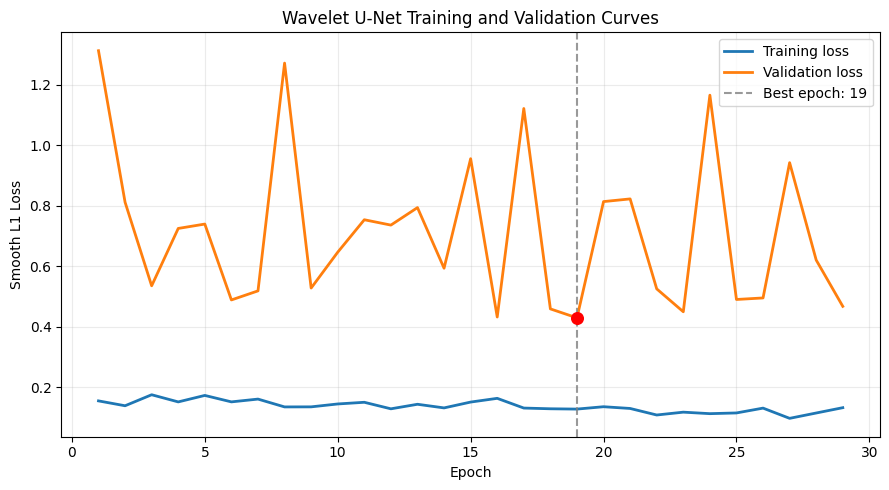

Best epoch: 19
Best validation loss: 0.4291


In [13]:
# adding training and validation history
history_df = pd.DataFrame(history)

best_epoch = int(history_df.loc[
    history_df["val_loss"].idxmin(), "epoch"
])
best_val_loss = history_df["val_loss"].min()

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training loss",
    linewidth=2,
)

ax.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation loss",
    linewidth=2,
)

ax.axvline(
    best_epoch,
    color="gray",
    linestyle="--",
    alpha=0.8,
    label=f"Best epoch: {best_epoch}",
)

ax.scatter(
    best_epoch,
    best_val_loss,
    color="red",
    s=70,
    zorder=3,
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Smooth L1 Loss")
ax.set_title("Wavelet U-Net Training and Validation Curves")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(
    FIG_DIR / "training_validation_curves.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")

## 8. Final patient-level comparison and saved results

,model,split,target,MAE,RMSE,R2
0,Features: Ridge,test,FM,0.042553,0.059954,0.654797
1,Features: Ridge,test,FFM,0.350257,0.411436,-0.197290
2,Wavelet U-Net regressor,test,FM,0.075172,0.117286,-0.321074
3,Wavelet U-Net regressor,test,FFM,0.325963,0.341054,0.177301


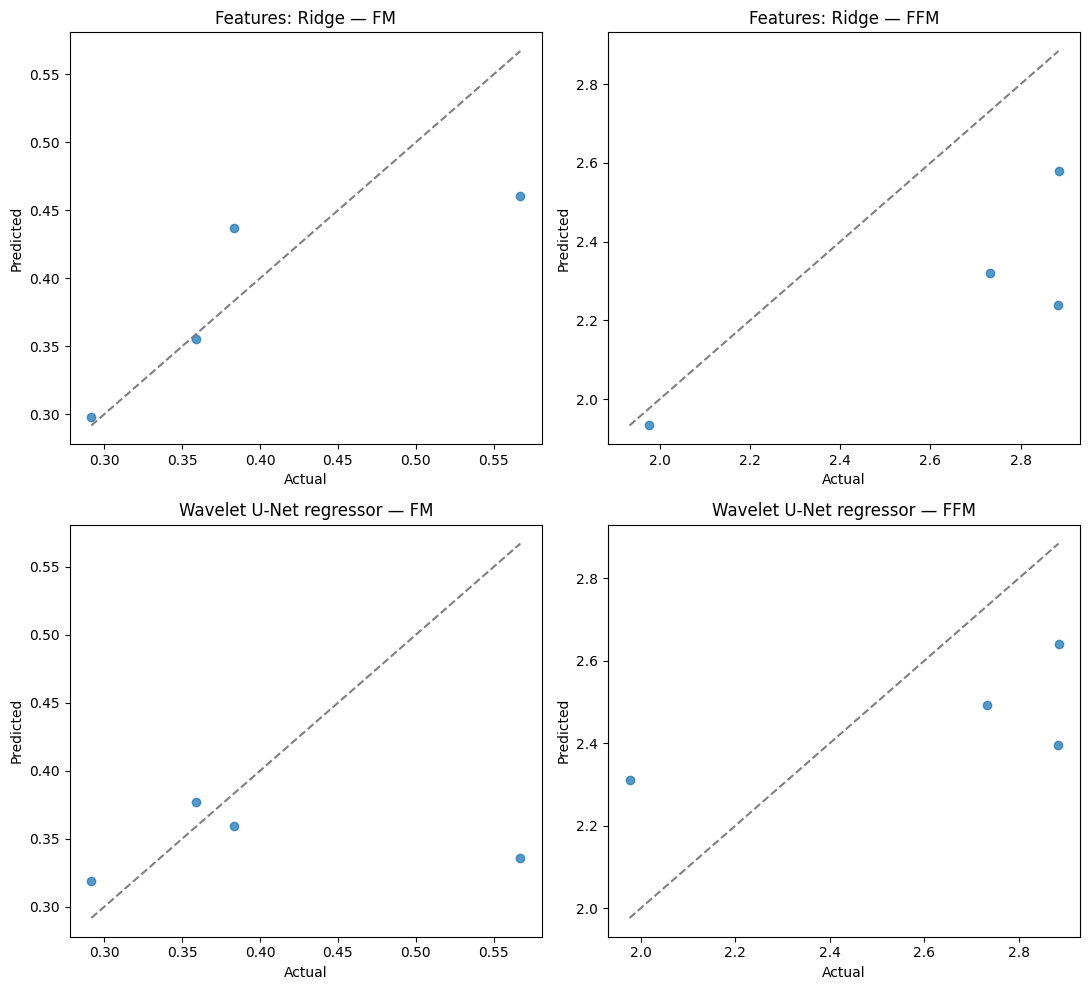

Saved reusable crops, features, splits, models, predictions, metrics, and figures to:
/content/gdrive/MyDrive/Body Composition 2026/wavelet_unet_results


In [14]:
def predict_deep(loader):
    model.eval()
    predictions, actuals, patient_ids = [], [], []
    with torch.no_grad():
        for x, y, pid in loader:
            pred = model(x.to(device)).cpu().numpy() * target_std + target_mean
            actual = y.numpy() * target_std + target_mean
            predictions.append(pred); actuals.append(actual); patient_ids.extend(pid)
    meta = pd.DataFrame({'patient_id': patient_ids})
    return patient_predictions(meta, np.vstack(actuals), np.vstack(predictions))

# The feature model is evaluated on the exact same untouched test patients.
feature_test_pred = best_feature_model.predict(X.loc[test_mask])
feature_test = patient_predictions(df_features.loc[test_mask], y[test_mask], feature_test_pred)
deep_test = predict_deep(loaders['test'])

metrics = pd.DataFrame(
    regression_metrics(feature_test, f'Features: {best_feature_name}', 'test') +
    regression_metrics(deep_test, 'Wavelet U-Net regressor', 'test')
)
display(metrics)
metrics.to_csv(OUTPUT_DIR / 'test_metrics.csv', index=False)
feature_test.to_csv(OUTPUT_DIR / 'feature_patient_predictions.csv', index=False)
deep_test.to_csv(OUTPUT_DIR / 'unet_patient_predictions.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for row_index, (name, table) in enumerate([(f'Features: {best_feature_name}', feature_test),
                                           ('Wavelet U-Net regressor', deep_test)]):
    for col_index, target in enumerate(('fm', 'ffm')):
        ax = axes[row_index, col_index]
        actual, pred = table[f'{target}_actual'], table[f'{target}_pred']
        ax.scatter(actual, pred, alpha=0.75)
        low, high = min(actual.min(), pred.min()), max(actual.max(), pred.max())
        ax.plot([low, high], [low, high], '--', color='gray')
        ax.set(xlabel='Actual', ylabel='Predicted', title=f'{name} — {target.upper()}')
fig.tight_layout()
fig.savefig(FIG_DIR / 'test_actual_vs_predicted.png', dpi=200, bbox_inches='tight')
plt.show()

print('Saved reusable crops, features, splits, models, predictions, metrics, and figures to:')
print(OUTPUT_DIR)